# 2 TLS Non-Markovian Example

This example evolves two TLSs in a delayed waveguide and tracks system populations together with the loop and output fields.

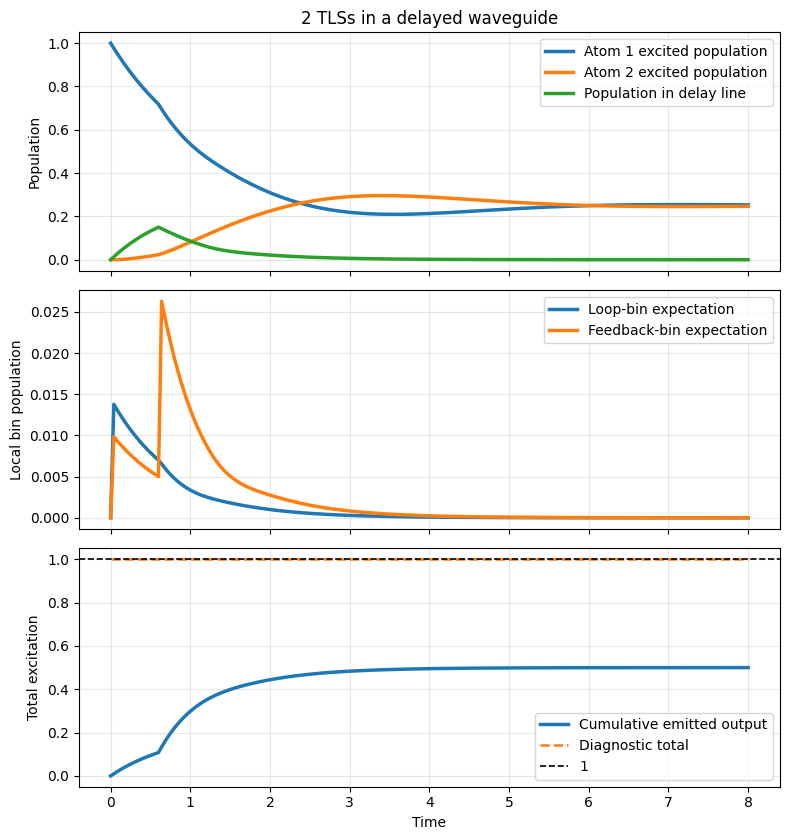

(InputParams(delta_t=0.04, tmax=8.0, d_sys_total=array([2, 2]), d_t_total=array([2]), bond_max=20, gamma_l=0.25, gamma_r=0.35, gamma_l2=0.35, gamma_r2=0.25, g=0.0, tau=0.6, phase=1.0471975511965976, atol=1e-12, svd_driver='gesdd'),
 Bins(system_states=[array([[[0.+0.j],
         [0.+0.j],
         [1.+0.j],
         [0.+0.j]]]), array([[[-0.00000000e+00+0.00000000e+00j,
          -5.65006881e-20+1.17377292e-01j],
         [-1.19520767e-02+4.34068718e-19j,
           5.06244570e-20-2.03617144e-19j],
         [ 9.88047923e-01-4.33294663e-19j,
          -4.02233285e-19+0.00000000e+00j],
         [ 0.00000000e+00+0.00000000e+00j,
           0.00000000e+00+0.00000000e+00j]],
 
        [[ 8.59113809e-02-4.96009589e-02j,
           5.70128004e-18+1.62893715e-18j],
         [ 1.72087896e-19+8.60439478e-20j,
          -1.41287776e-36+2.82575552e-36j],
         [ 0.00000000e+00+0.00000000e+00j,
           0.00000000e+00+0.00000000e+00j],
         [ 0.00000000e+00+0.00000000e+00j,
           0.00

In [ ]:
from __future__ import annotations

import time as t

import matplotlib.pyplot as plt
import numpy as np
import wqedmps as qmps


def two_tls_product_state(atom1_excited: bool, atom2_excited: bool) -> np.ndarray:
    """Build a local product tensor |atom1> ⊗ |atom2>."""
    atom1 = (
        np.array([0.0, 1.0], dtype=complex)
        if atom1_excited
        else np.array([1.0, 0.0], dtype=complex)
    )
    atom2 = (
        np.array([0.0, 1.0], dtype=complex)
        if atom2_excited
        else np.array([1.0, 0.0], dtype=complex)
    )
    return np.kron(atom1, atom2).reshape(1, 4, 1)


def _delay_window_total(per_bin: np.ndarray, delay_steps: int) -> np.ndarray:
    """Accumulate the population currently stored over one delay window."""
    values = np.asarray(per_bin, dtype=float)
    if delay_steps <= 0:
        return np.zeros_like(values)

    csum = np.cumsum(values)
    total = csum.copy()
    if len(values) > delay_steps:
        total[delay_steps:] = csum[delay_steps:] - csum[:-delay_steps]
    return total


def run_two_tls_non_markovian_example(
    show: bool = True,
) -> tuple[qmps.InputParams, qmps.Bins, dict[str, np.ndarray | float]]:
    """Run a 2-TLS delayed-waveguide example."""
    params = qmps.InputParams(
        delta_t=0.04,
        tmax=8.0,
        tau=0.6,
        d_sys_total=np.array([2, 2]),
        d_t_total=np.array([2]),
        gamma_l=0.25,
        gamma_r=0.35,
        gamma_l2=0.35,
        gamma_r2=0.25,
        phase=np.pi / 3.0,
        bond_max=20,
        atol=1e-12,
    )

    initial_system = two_tls_product_state(atom1_excited=True, atom2_excited=False)
    initial_field = qmps.vacuum(params.tmax, params)

    start_time = t.time()
    hamiltonian = qmps.hamiltonian_2tls_nmar(params)
    bins = qmps.t_evol_nmar_seemps(
        hamiltonian,
        initial_system,
        initial_field,
        params,
    )

    times = np.asarray(bins.times, dtype=float)
    atom1_pop_op = np.kron(qmps.tls_pop(2), np.eye(2, dtype=complex))
    atom2_pop_op = np.kron(np.eye(2, dtype=complex), qmps.tls_pop(2))

    atom1_pop = np.asarray(
        qmps.single_time_expectation(bins.system_states, atom1_pop_op),
        dtype=float,
    )
    atom2_pop = np.asarray(
        qmps.single_time_expectation(bins.system_states, atom2_pop_op),
        dtype=float,
    )
    loop_bin_pop = np.asarray(
        qmps.single_time_expectation(bins.loop_field_states, qmps.num_op(params.d_t)),
        dtype=float,
    )
    feedback_bin_pop = np.asarray(
        qmps.single_time_expectation(bins.output_field_states, qmps.num_op(params.d_t)),
        dtype=float,
    )

    delay_total_pop = _delay_window_total(loop_bin_pop, params.delay_steps)
    emitted_output = np.cumsum(feedback_bin_pop)
    total_excitation = atom1_pop + atom2_pop + delay_total_pop + emitted_output

    runtime = float(t.time() - start_time)
    observables = {
        "times": times,
        "atom1_pop": atom1_pop,
        "atom2_pop": atom2_pop,
        "loop_bin_pop": loop_bin_pop,
        "feedback_bin_pop": feedback_bin_pop,
        "delay_total_pop": delay_total_pop,
        "emitted_output": emitted_output,
        "total_excitation": total_excitation,
        "runtime": runtime,
        "max_abs_error": float(np.max(np.abs(total_excitation - 1.0))),
    }

    if show:
        fig, axes = plt.subplots(3, 1, figsize=(8.0, 8.5), sharex=True)

        axes[0].plot(times, atom1_pop, lw=2.5, label="Atom 1 excited population")
        axes[0].plot(times, atom2_pop, lw=2.5, label="Atom 2 excited population")
        axes[0].plot(times, delay_total_pop, lw=2.5, label="Population in delay line")
        axes[0].set_ylabel("Population")
        axes[0].set_title("2 TLSs in a delayed waveguide")
        axes[0].legend()
        axes[0].grid(alpha=0.3)

        axes[1].plot(times, loop_bin_pop, lw=2.5, label="Loop-bin expectation")
        axes[1].plot(times, feedback_bin_pop, lw=2.5, label="Feedback-bin expectation")
        axes[1].set_ylabel("Local bin population")
        axes[1].legend()
        axes[1].grid(alpha=0.3)

        axes[2].plot(times, emitted_output, lw=2.5, label="Cumulative emitted output")
        axes[2].plot(times, total_excitation, "--", lw=1.8, label="Diagnostic total")
        axes[2].axhline(1.0, color="k", linestyle="--", lw=1.2, label="1")
        axes[2].set_xlabel("Time")
        axes[2].set_ylabel("Total excitation")
        axes[2].legend()
        axes[2].grid(alpha=0.3)

        plt.tight_layout()
        plt.show()

    return params, bins, observables


run_two_tls_non_markovian_example()
